## Objectives

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("oktayrdeki/houses-in-london")

print("Path to dataset files:", path)

100%|██████████| 20.8k/20.8k [00:00<00:00, 408kB/s]

Extracting files...
Path to dataset files: C:\Users\Renanzin\.cache\kagglehub\datasets\oktayrdeki\houses-in-london\versions\1


In [24]:
import pandas as pd
import seaborn as sns
import numpy as np

In [3]:
dataset = pd.read_csv("data//london_houses.csv")

In [4]:
dataset.head()

,Address,Neighborhood,Bedrooms,Bathrooms,Square Meters,Building Age,Garden,Garage,Floors,Property Type,Heating Type,Balcony,Interior Style,View,Materials,Building Status,Price (£)
0,78 Regent Street,Notting Hill,2,3,179,72,No,No,3,Semi-Detached,Electric Heating,High-level Balcony,Industrial,Garden,Marble,Renovated,2291200
1,198 Oxford Street,Westminster,2,1,123,34,Yes,No,1,Apartment,Central Heating,High-level Balcony,Industrial,City,Laminate Flooring,Old,1476000
2,18 Regent Street,Soho,5,3,168,38,No,Yes,3,Semi-Detached,Central Heating,No Balcony,Industrial,Street,Wood,Renovated,1881600
3,39 Piccadilly Circus,Islington,5,1,237,53,Yes,Yes,1,Apartment,Underfloor Heating,No Balcony,Classic,Park,Granite,Renovated,1896000
4,116 Fleet Street,Marylebone,4,1,127,23,No,Yes,2,Semi-Detached,Central Heating,No Balcony,Modern,Park,Wood,Old,1524000


In [5]:
# Finding more informations
# The info() method displays a summary of the DataFrame, including the number of rows and columns,
# column names, data types, non-null values, and memory usage.
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Address          1000 non-null   object
 1   Neighborhood     1000 non-null   object
 2   Bedrooms         1000 non-null   int64 
 3   Bathrooms        1000 non-null   int64 
 4   Square Meters    1000 non-null   int64 
 5   Building Age     1000 non-null   int64 
 6   Garden           1000 non-null   object
 7   Garage           1000 non-null   object
 8   Floors           1000 non-null   int64 
 9   Property Type    1000 non-null   object
 10  Heating Type     1000 non-null   object
 11  Balcony          1000 non-null   object
 12  Interior Style   1000 non-null   object
 13  View             1000 non-null   object
 14  Materials        1000 non-null   object
 15  Building Status  1000 non-null   object
 16  Price (£)        1000 non-null   int64 
dtypes: int64(6), object(11)
memory usa

In [6]:
# The describe() method generates descriptive statistics for the DataFrame,
# such as count, mean, standard deviation, minimum, maximum, and quartiles.
dataset["Bedrooms"].describe()

count    1000.000000
mean        3.013000
std         1.393834
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Bedrooms, dtype: float64

In [42]:
dataset['Price (£)'].describe()

count    1.000000e+03
mean     1.840807e+06
std      8.793484e+05
min      3.866660e+05
25%      1.161400e+06
50%      1.721999e+06
75%      2.390500e+06
max      4.980000e+06
Name: Price (£), dtype: float64

In [7]:
dataset["Neighborhood"].value_counts()

Neighborhood
Kensington      114
Marylebone      113
Camden          106
Westminster      98
Islington        97
Greenwich        97
Notting Hill     96
Soho             96
Chelsea          94
Shoreditch       89
Name: count, dtype: int64

In [9]:
# The select_dtypes() method filters columns by data type.
# The corr() method calculates the correlation between numeric columns (pearson correlation).
# The abs() function returns the absolute value of each correlation.
# The sort_values() method sorts the values in ascending or descending order.
# The format() method inserts values into a string.

# Select only the integer columns from the original DataFrame.
dataset_int = dataset.select_dtypes(include=['int64'])
# Calculate the correlation of each integer column with the Price column.
dataset_int_corr = dataset_int.corr()['Price (£)'][:-1]
# Keep only features with strong correlation and sort them from highest to lowest.
top_features = dataset_int_corr[abs(dataset_int_corr) > 0.5].sort_values(ascending=False)
# Print how many strongly correlated features were found and list them.
print("There is {} strongly correlated values with SalePrice: \n{}".format(len(top_features), top_features))

There is 1 strongly correlated values with SalePrice: 
Square Meters    0.790652
Name: Price (£), dtype: float64


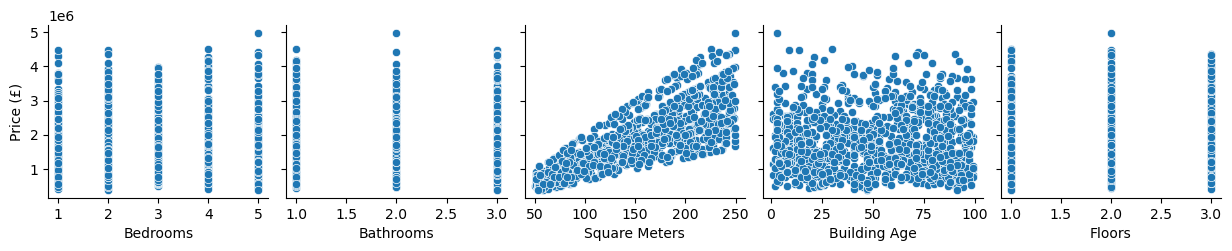

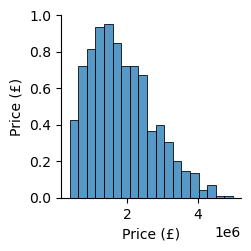

In [21]:
for i in range(0, len(dataset_int.columns), 5):
    sns.pairplot(data=dataset_int,
                 x_vars=dataset_int.columns[i:i+5],
                 y_vars=['Price (£)'])

0.6513082699899329

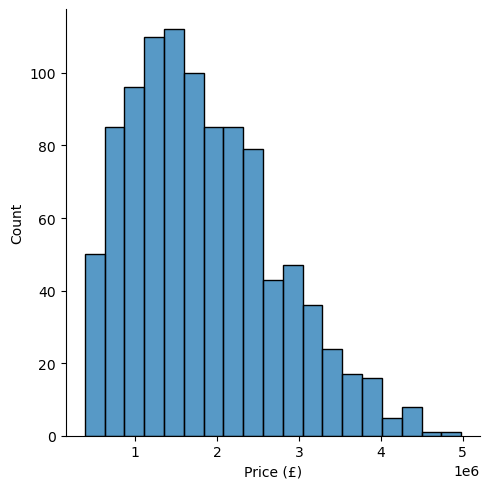

In [ ]:
# Log Transformation
# Inspect if 'Price (£)' are normally distributed
dataset_unstransformed = sns.displot(dataset['Price (£)'])
# Print the skewness
dataset['Price (£)'].skew()

<class 'pandas.core.series.Series'>


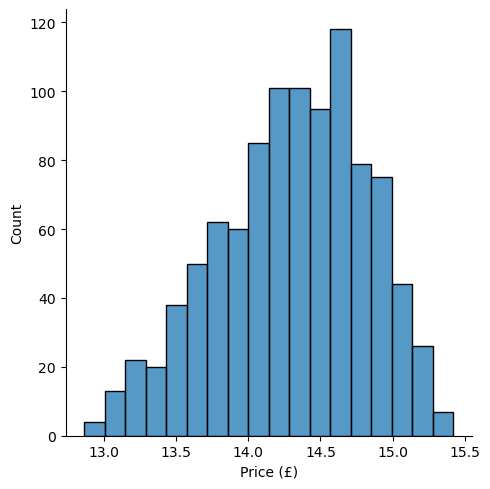

In [ ]:
log_transformed = np.log(dataset['Price (£)'])
sns.displot(log_transformed)

In [39]:
print("Skewness: %f" % (log_transformed).skew())

Skewness: -0.363630


### Interpreting the log transformation

As we can see, the log transformation made the `Price (£)` distribution more symmetrical and closer to a bell curve. In other words, the right tail became less stretched, which reduced the skewness and brought the data closer to the normality assumption often used in regression analysis.

There are other ways to correct skewness besides `np.log()`. Two common alternatives are the Square Root Transform (`np.sqrt`) and the Box-Cox Transform (`stats.boxcox` from `scipy`). The Box-Cox method can be especially useful when we want to search for a transformation that makes the data more normally distributed, but it only works with strictly positive values.

Reference: [Top 3 Methods for Handling Skewed Data](https://towardsdatascience.com/top-3-methods-for-handling-skewed-data-1334e0debf45)


In [41]:
from scipy import stats

price = dataset['Price (£)'].dropna()

sqrt_transformed = np.sqrt(price)
boxcox_transformed, boxcox_lambda = stats.boxcox(price)

comparison = pd.DataFrame({
    'Original': [price.skew()],
    'Log': [log_transformed.skew()],
    'Square Root': [sqrt_transformed.skew()],
    'Box-Cox': [pd.Series(boxcox_transformed).skew()]
})

print(f"Box-Cox lambda: {boxcox_lambda:.4f}")
comparison


Box-Cox lambda: 0.3123


,Original,Log,Square Root,Box-Cox
0,0.651308,-0.36363,0.155734,-0.035525


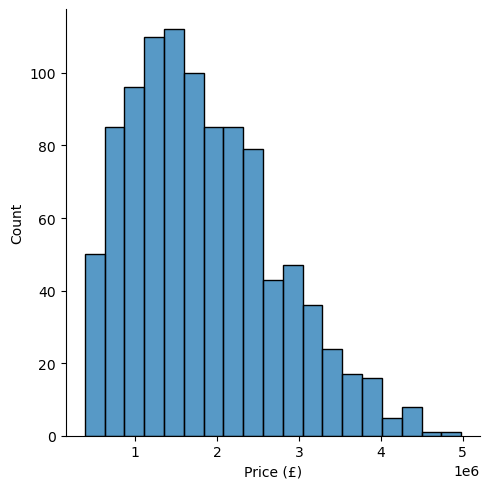

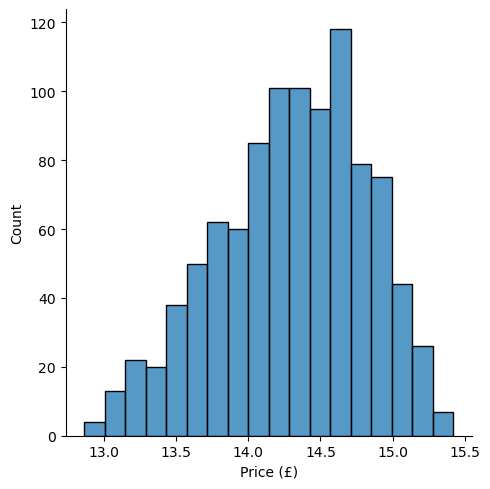

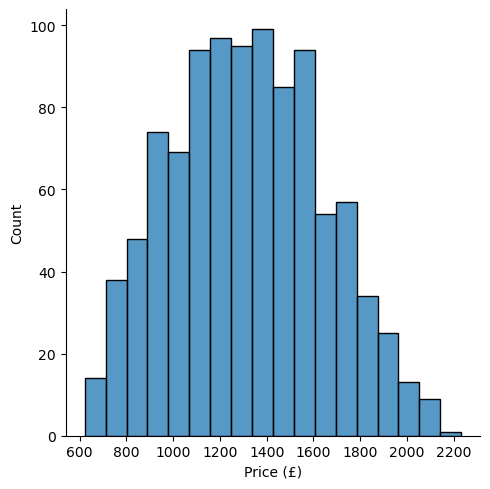

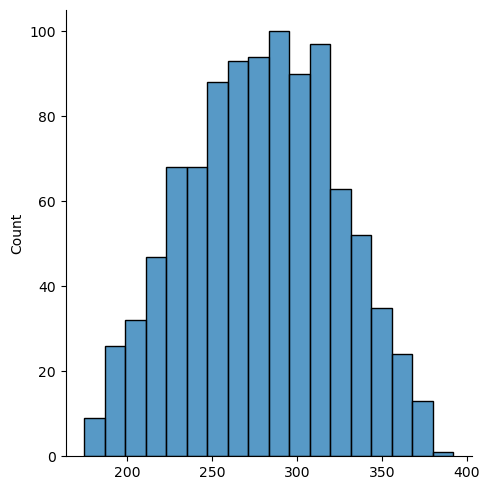

In [43]:
sns.displot(price)
sns.displot(log_transformed)
sns.displot(sqrt_transformed)
sns.displot(boxcox_transformed)


### Practical note

- `np.log()` is a strong option when the data are right-skewed and all values are positive.
- `np.sqrt()` is usually a lighter transformation than log and may help when the skewness is moderate.
- `stats.boxcox()` is more flexible because it estimates the best power transformation automatically.
- After transforming the data, compare the new skewness and inspect the plots again before choosing which version to use in the model.
